In [7]:
import pandas as pd
import numpy as np

# Load dataset (change filename if needed)
df = pd.read_csv("C:\\Users\\venni\\OneDrive\\Desktop\\Fraud Detection\\creditcard.csv")

# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

# First few rows
df.head()

Shape of dataset: (284807, 31)

Column names:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
target_col = "Class"
print("Class distribution (count):")
print(df[target_col].value_counts())
print("----")
print("Class distribution (percentage):")
df[target_col].value_counts(normalize=True) * 100




Class distribution (count):
Class
0    284315
1       492
Name: count, dtype: int64
----
Class distribution (percentage):


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [9]:
print("Total missing values in dataset:")
print(df.isnull().sum().sum())


Total missing values in dataset:
0


In [10]:
print("Number of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
1081


In [11]:
print("Data types of columns:")
df.dtypes


Data types of columns:


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [13]:
num_features = df.drop(columns=[target_col]).columns.tolist()

print("Number of input features:", len(num_features))
print("Sample features:", num_features[:5])

Number of input features: 30
Sample features: ['Time', 'V1', 'V2', 'V3', 'V4']


In [14]:
X = df.drop(columns=[target_col])
y = df[target_col]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])


In [17]:
print(X_train.shape)
print(X_test.shape)

print("Fraud ratio in train set:")
print(y_train.value_counts(normalize=True) * 100)

print("Fraud ratio in test set:")
print(y_test.value_counts(normalize=True) * 100)


(227845, 30)
(56962, 30)
Fraud ratio in train set:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64
Fraud ratio in test set:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Evaluation
print("LOGISTIC REGRESSION")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


LOGISTIC REGRESSION
Confusion Matrix:
[[56850    14]
 [   33    65]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.66      0.73        98

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9487301603252443


c:\Users\venni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("\nDECISION TREE")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))



DECISION TREE
Confusion Matrix:
[[56840    24]
 [   25    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.8722379497662881


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nRANDOM FOREST")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))



RANDOM FOREST
Confusion Matrix:
[[56859     5]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9630272515590367


In [21]:
from imblearn.over_sampling import SMOTE
print("Before SMOTE:")
print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:")
print(y_train_smote.value_counts())



Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [23]:
y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

print("RANDOM FOREST + SMOTE")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))


RANDOM FOREST + SMOTE
Confusion Matrix:
[[56847    17]
 [   17    81]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9691768150000575


In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)


In [25]:
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [26]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST + SMOTE")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


XGBOOST + SMOTE
Confusion Matrix:
[[56832    32]
 [   14    84]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9825918338635398


In [27]:
from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

print("After SMOTE-Tomek:")
print(y_train_st.value_counts())

After SMOTE-Tomek:
Class
0    227207
1    227207
Name: count, dtype: int64


In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_st = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_st.fit(X_train_st, y_train_st)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [29]:
y_pred_st = xgb_st.predict(X_test)
y_prob_st = xgb_st.predict_proba(X_test)[:, 1]

print("XGBOOST + SMOTE-TOMEK")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_st))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_st))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_st))


XGBOOST + SMOTE-TOMEK
Confusion Matrix:
[[56835    29]
 [   14    84]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9810252604136759


In [30]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [31]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1
)


In [32]:
from imblearn.combine import SMOTETomek


In [33]:
smote_tomek = SMOTETomek(random_state=42)

X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)


In [34]:
lgbm.fit(X_train_st, y_train_st)


[LightGBM] [Info] Number of positive: 227207, number of negative: 227207
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454414, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               n_jobs=-1, objective='binary', random_state=42, subsample=0.8)

In [35]:
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("LIGHTGBM + SMOTE-TOMEK")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))


LIGHTGBM + SMOTE-TOMEK
Confusion Matrix:
[[56831    33]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.987598767700665


In [36]:
X_tr = X_train_st
y_tr = y_train_st


In [37]:
neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()

scale = neg / pos
print("scale_pos_weight:", scale)


scale_pos_weight: 1.0


In [38]:
from xgboost import XGBClassifier

xgb_cs = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,     # ⭐ cost sensitivity
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_cs.fit(X_tr, y_tr)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [39]:
y_prob_cs = xgb_cs.predict_proba(X_test)[:, 1]


In [40]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred_05 = (y_prob_cs >= 0.5).astype(int)

print("Threshold = 0.5")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cs))


Threshold = 0.5
[[56840    24]
 [   13    85]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.87      0.82        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9832166687721797


In [41]:
y_pred_045 = (y_prob_cs >= 0.45).astype(int)

print("Threshold = 0.45")
print(confusion_matrix(y_test, y_pred_045))
print(classification_report(y_test, y_pred_045))


Threshold = 0.45
[[56836    28]
 [   13    85]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.87      0.81        98

    accuracy                           1.00     56962
   macro avg       0.88      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
y_pred_04 = (y_prob_cs >= 0.40).astype(int)

print("Threshold = 0.40")
print(confusion_matrix(y_test, y_pred_04))
print(classification_report(y_test, y_pred_04))


Threshold = 0.40
[[56833    31]
 [   13    85]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [43]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [44]:
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train, y_train)


BalancedRandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [45]:
y_pred_brf = brf.predict(X_test)
y_prob_brf = brf.predict_proba(X_test)[:, 1]

print("BALANCED RANDOM FOREST")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_brf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_brf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_brf))


BALANCED RANDOM FOREST
Confusion Matrix:
[[56248   616]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC: 0.9777435312898372


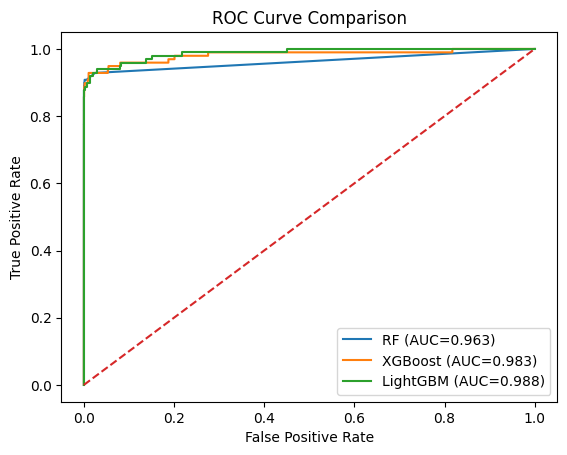

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost (final)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC={auc_lgbm:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


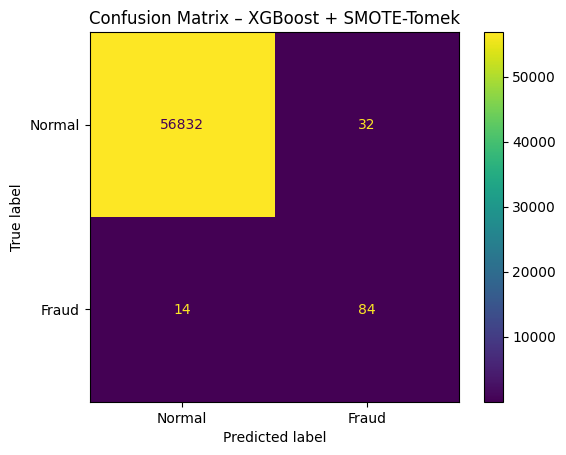

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["Normal", "Fraud"]
)
plt.title("Confusion Matrix – XGBoost + SMOTE-Tomek")
plt.show()


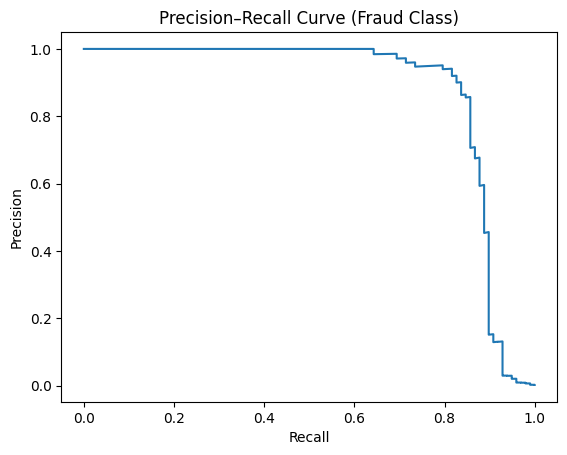

In [48]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Fraud Class)")
plt.show()


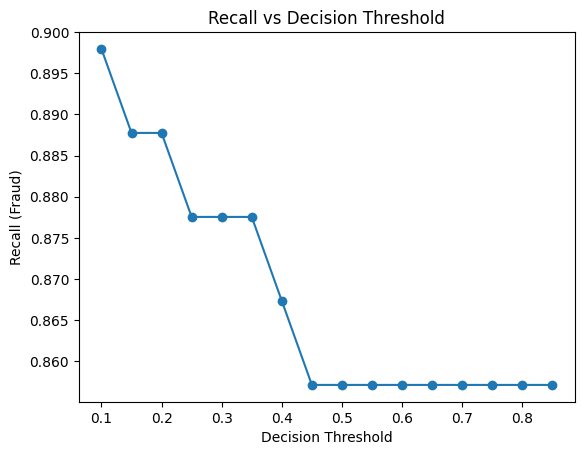

In [49]:
import numpy as np
from sklearn.metrics import recall_score

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure()
plt.plot(thresholds, recalls, marker="o")
plt.xlabel("Decision Threshold")
plt.ylabel("Recall (Fraud)")
plt.title("Recall vs Decision Threshold")
plt.show()


In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


In [51]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

avg_precision = average_precision_score(y_test, y_prob_xgb)
print("Average Precision (AP):", avg_precision)


Average Precision (AP): 0.8761891200266508


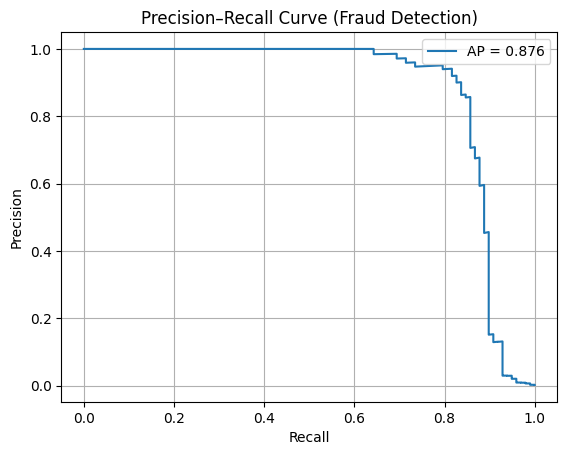

In [52]:
plt.figure()
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Fraud Detection)")
plt.legend()
plt.grid(True)
plt.show()


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score


In [54]:
thresholds = np.arange(0.1, 0.9, 0.05)


In [55]:
recalls = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    recalls.append(recall)


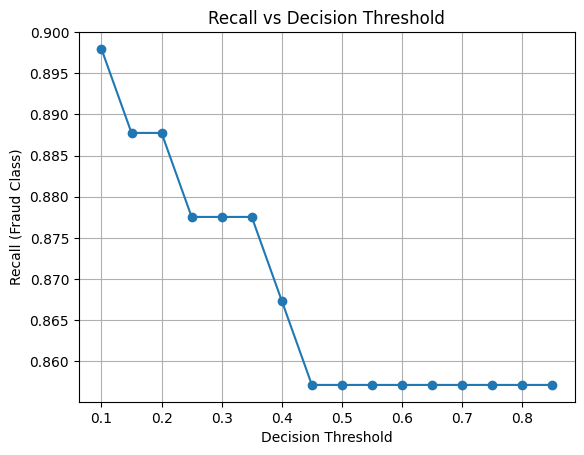

In [56]:
plt.figure()
plt.plot(thresholds, recalls, marker="o")
plt.xlabel("Decision Threshold")
plt.ylabel("Recall (Fraud Class)")
plt.title("Recall vs Decision Threshold")
plt.grid(True)
plt.show()


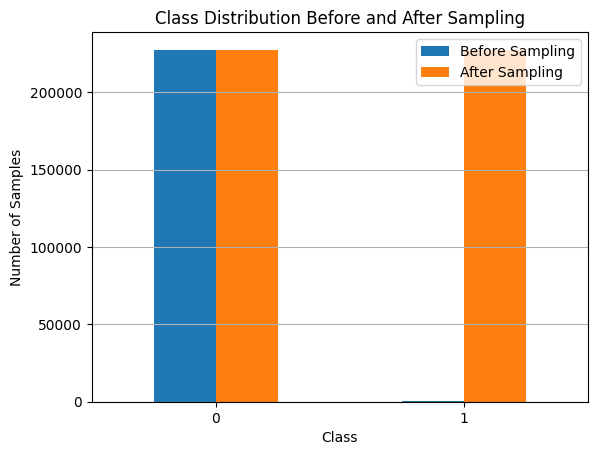

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Create counts
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_st.value_counts().sort_index()

# Create DataFrame for plotting
df_plot = pd.DataFrame({
    "Before Sampling": before_counts,
    "After Sampling": after_counts
})

# Plot
df_plot.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before and After Sampling")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.show()
